# 🗺️ UMAP: Uniform Manifold Approximation and Projection
## A Complete, Beginner-Friendly Implementation

---

### 📦 Datasets Used

| Dataset | Samples | Features | Classes | Source |
|---------|---------|----------|---------|--------|
| **Iris** | 150 | 4 | 3 species | `sklearn.datasets.load_iris()` |
| **Breast Cancer Wisconsin** | 569 | 30 | 2 (malignant/benign) | `sklearn.datasets.load_breast_cancer()` |
| **MNIST (subset)** | 5,000 | 784 | 10 digits | `sklearn.datasets.fetch_openml('mnist_784')` |

### 🎯 What You Will Learn
1. How UMAP builds a fuzzy graph from high-dimensional data
2. How to apply and interpret UMAP visualizations correctly
3. How UMAP compares to PCA and t-SNE on real datasets
4. How `n_neighbors` and `min_dist` change the embedding
5. How to use UMAP's `transform()` for new data — something t-SNE cannot do

### ⏱️ Estimated Runtime: 3–6 minutes

> 💡 **Before running:** Install umap-learn if needed: `pip install umap-learn`

---

---
## Cell 2 — 📦 Imports

| Library | Role |
|---------|------|
| `umap` | The main algorithm — install via `pip install umap-learn` |
| `sklearn.manifold.TSNE` | For comparison with t-SNE |
| `sklearn.decomposition.PCA` | For comparison with PCA |
| `sklearn.preprocessing.StandardScaler` | Feature normalization before UMAP |
| `sklearn.datasets` | Iris, Breast Cancer, MNIST |
| `matplotlib / seaborn` | Visualization |
| `numpy / pandas` | Data manipulation |

In [1]:
# ── Core libraries ─────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import time
import warnings
warnings.filterwarnings('ignore')

# ── Visualization ──────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── Dimensionality reduction ───────────────────────────────────────────────────
import umap                                        # pip install umap-learn
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA

# ── Data preprocessing ─────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# ── Datasets ───────────────────────────────────────────────────────────────────
from sklearn.datasets import load_iris, load_breast_cancer, fetch_openml

# ── Evaluation ─────────────────────────────────────────────────────────────────
from sklearn.metrics import silhouette_score

# ── Global settings ────────────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('tab10')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ All libraries imported successfully!")
print(f"   umap-learn version : {umap.__version__}")
import sklearn
print(f"   scikit-learn version: {sklearn.__version__}")

✅ All libraries imported successfully!
   umap-learn version : 0.5.12
   scikit-learn version: 1.9.0


---
## Cell 3 — 🧠 Theory Recap: UMAP in Plain English

### The Crumpled Paper Analogy

Imagine a piece of paper crumpled into a ball. The paper itself is 2D — it has an intrinsic flat structure — but it exists in 3D space. High-dimensional data is similar: a 784-feature MNIST image lives in 784D space, but the *meaningful* structure ("this is a 7") is much lower-dimensional.

UMAP is the algorithm that **uncrumples** that paper. It finds the low-dimensional manifold structure that the data actually lives on.

### Two-Phase Process

```
PHASE 1: BUILD THE MAP (high-dimensional)
  ├── Find k nearest neighbors per point       ← controlled by n_neighbors
  ├── Convert distances to fuzzy probabilities  ← local normalization (ρᵢ, σᵢ)
  └── Symmetrize → weighted graph W             ← fuzzy union formula

PHASE 2: DRAW THE MAP (low-dimensional)
  ├── Initialize with spectral layout           ← globally coherent start
  ├── Compute low-dim similarities q_ij         ← controlled by min_dist
  └── Minimize cross-entropy(W, Q) via SGD      ← attractive + repulsive forces
```

### Why UMAP beats t-SNE on global structure

| | t-SNE | UMAP |
|-|-------|------|
| Initialization | Random | Spectral (globally coherent) |
| Loss function | KL divergence (one-sided) | Cross-entropy (symmetric) |
| Repulsive forces | Weak / indirect | Explicit negative sampling |
| Result | Local clusters, global positions arbitrary | Local clusters + meaningful global layout |

### ⚠️ Critical Interpretability Rules

| Rule | Explanation |
|------|-------------|
| ✅ Within-cluster proximity | Meaningful — nearby points are genuinely similar |
| ⚠️ Between-cluster distances | More meaningful than t-SNE, but still use with caution |
| ❌ Cluster sizes | Do NOT reflect real data density |
| ❌ Axes (x, y) | Have no unit or interpretable meaning |
| ✅ Consistent structure | If clusters appear across multiple seeds/parameters, they're likely real |

---
## Cell 4 — 📊 Load Datasets

We use three real datasets with increasing complexity to demonstrate UMAP at different scales.

In [2]:
# ── Dataset 1: Iris ────────────────────────────────────────────────────────────
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
iris_names = iris.target_names
iris_features = iris.feature_names

# ── Dataset 2: Breast Cancer Wisconsin ────────────────────────────────────────
bc = load_breast_cancer()
X_bc, y_bc = bc.data, bc.target
bc_names = bc.target_names      # ['malignant', 'benign']
bc_features = bc.feature_names

# ── Dataset 3: MNIST (subset) ─────────────────────────────────────────────────
print("Loading MNIST... (first run downloads ~12 MB)")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_mnist_full = mnist.data.astype(np.float32)
y_mnist_full = mnist.target.astype(int)

# Subsample 5000 points for speed
N = 5000
idx = np.random.choice(len(X_mnist_full), N, replace=False)
X_mnist, y_mnist = X_mnist_full[idx], y_mnist_full[idx]

# ── Summary ────────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("         DATASET OVERVIEW")
print("=" * 60)
for name, X, y, labels in [
    ("Iris",           X_iris,  y_iris, iris_names),
    ("Breast Cancer",  X_bc,    y_bc,   bc_names),
    ("MNIST (subset)", X_mnist, y_mnist, [str(i) for i in range(10)])
]:
    print(f"\n  {name}")
    print(f"    Shape  : {X.shape}")
    print(f"    Classes: {list(labels)}")
    print(f"    Per class: {np.bincount(y).tolist()}")

print("\n" + "=" * 60)

# ── Show Breast Cancer DataFrame head ─────────────────────────────────────────
print("\nBreast Cancer — first 5 rows:")
df_bc = pd.DataFrame(X_bc, columns=bc_features)
df_bc['diagnosis'] = [bc_names[i] for i in y_bc]
display(df_bc.head())

print("\nBasic statistics (Breast Cancer):")
display(df_bc.describe().round(3))

Loading MNIST... (first run downloads ~12 MB)

         DATASET OVERVIEW

  Iris
    Shape  : (150, 4)
    Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
    Per class: [50, 50, 50]

  Breast Cancer
    Shape  : (569, 30)
    Classes: [np.str_('malignant'), np.str_('benign')]
    Per class: [212, 357]

  MNIST (subset)
    Shape  : (5000, 784)
    Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
    Per class: [490, 551, 483, 556, 433, 476, 490, 515, 489, 517]


Breast Cancer — first 5 rows:


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,malignant



Basic statistics (Breast Cancer):


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,...,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000,569.000
mean,14.127,19.290,91.969,654.889,0.096,0.104,0.089,0.049,0.181,0.063,...,16.269,25.677,107.261,880.583,0.132,0.254,0.272,0.115,0.290,0.084
std,3.524,4.301,24.299,351.914,0.014,0.053,0.080,0.039,0.027,0.007,...,4.833,6.146,33.603,569.357,0.023,0.157,0.209,0.066,0.062,0.018
min,6.981,9.710,43.790,143.500,0.053,0.019,0.000,0.000,0.106,0.050,...,7.930,12.020,50.410,185.200,0.071,0.027,0.000,0.000,0.156,0.055
25%,11.700,16.170,75.170,420.300,0.086,0.065,0.030,0.020,0.162,0.058,...,13.010,21.080,84.110,515.300,0.117,0.147,0.114,0.065,0.250,0.071
50%,13.370,18.840,86.240,551.100,0.096,0.093,0.062,0.034,0.179,0.062,...,14.970,25.410,97.660,686.500,0.131,0.212,0.227,0.100,0.282,0.080
75%,15.780,21.800,104.100,782.700,0.105,0.130,0.131,0.074,0.196,0.066,...,18.790,29.720,125.400,1084.000,0.146,0.339,0.383,0.161,0.318,0.092
max,28.110,39.280,188.500,2501.000,0.163,0.345,0.427,0.201,0.304,0.097,...,36.040,49.540,251.200,4254.000,0.223,1.058,1.252,0.291,0.664,0.208


---
## Cell 5 — 🔧 Preprocessing

### Why scaling is critical before UMAP

UMAP computes **pairwise distances** between all points. If one feature ranges from 0 to 1,000 and another from 0 to 0.001, the first feature will completely dominate the distance computation — and UMAP will effectively ignore all other features.

**Solution:** Use `StandardScaler` to set mean=0 and std=1 for every feature, giving each equal influence.

> **Note on MNIST:** Pixel values are already on the same scale (0–255), so we just normalize to [0, 1] rather than standardize — standardization can distort pixel distributions.

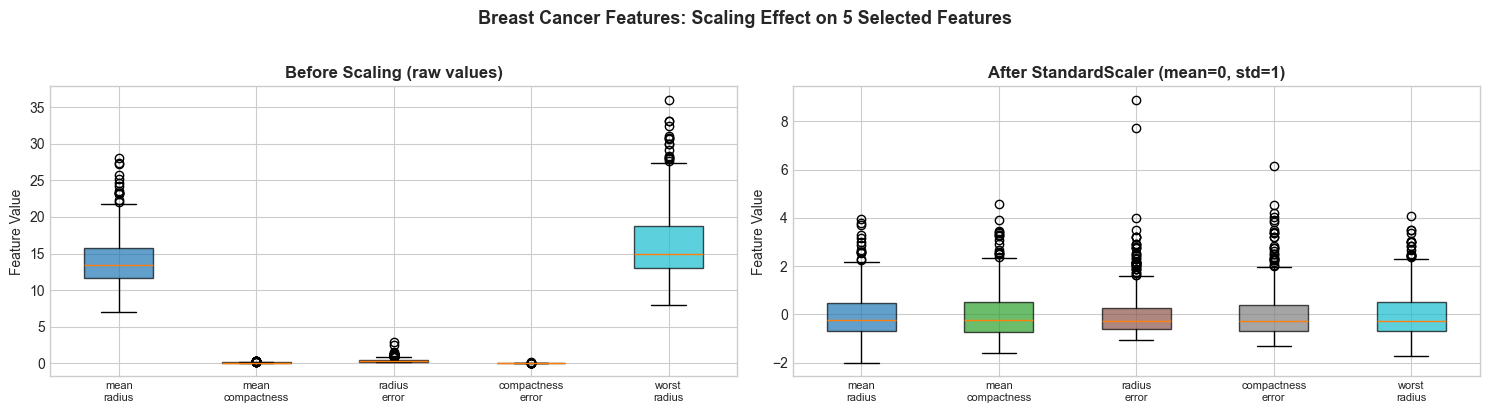

Before scaling — range per feature:
  mean radius                        : [6.98, 28.11]
  mean compactness                   : [0.02, 0.35]
  radius error                       : [0.11, 2.87]
  compactness error                  : [0.00, 0.14]
  worst radius                       : [7.93, 36.04]

After scaling — range per feature:
  mean radius                        : [-2.03, 3.97]
  mean compactness                   : [-1.61, 4.57]
  radius error                       : [-1.06, 8.91]
  compactness error                  : [-1.30, 6.14]
  worst radius                       : [-1.73, 4.09]

✅ Preprocessing complete. All datasets ready for UMAP.


In [3]:
# ── Scale each dataset ─────────────────────────────────────────────────────────
scaler = StandardScaler()

X_iris_scaled = scaler.fit_transform(X_iris)
X_bc_scaled   = scaler.fit_transform(X_bc)
X_mnist_norm  = X_mnist / 255.0          # Normalize pixels to [0, 1]

# ── Visual check: before vs after scaling (Breast Cancer) ─────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Pick 5 representative features to visualize
sample_features = [0, 5, 10, 15, 20]
feature_labels  = [bc_features[i].replace(' ', '\n') for i in sample_features]

for ax, data, title in [
    (axes[0], X_bc[:, sample_features],        'Before Scaling (raw values)'),
    (axes[1], X_bc_scaled[:, sample_features], 'After StandardScaler (mean=0, std=1)')
]:
    bp = ax.boxplot(data, patch_artist=True, labels=feature_labels)
    colors_box = plt.cm.tab10(np.linspace(0, 1, len(sample_features)))
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Feature Value')
    ax.tick_params(axis='x', labelsize=8)

plt.suptitle('Breast Cancer Features: Scaling Effect on 5 Selected Features',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Before scaling — range per feature:")
for i in sample_features:
    r = X_bc[:, i]
    print(f"  {bc_features[i][:35]:<35}: [{r.min():.2f}, {r.max():.2f}]")
print("\nAfter scaling — range per feature:")
for j, i in enumerate(sample_features):
    r = X_bc_scaled[:, i]
    print(f"  {bc_features[i][:35]:<35}: [{r.min():.2f}, {r.max():.2f}]")
print("\n✅ Preprocessing complete. All datasets ready for UMAP.")

---
## Cell 6 — 🔍 UMAP Logic: Conceptual Deep Dive

Before applying UMAP, let's build deep intuition for each phase.

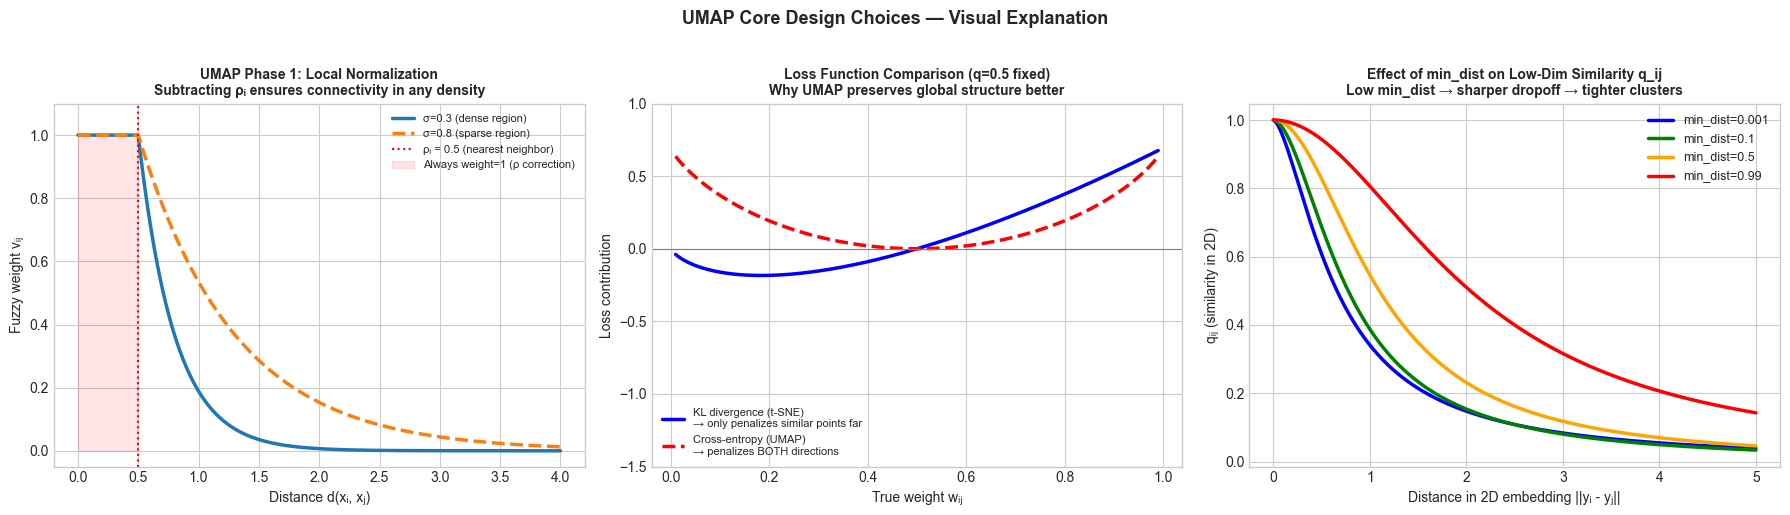

💡 Key insights from these plots:
   Left:   ρᵢ-correction means every point has at least one guaranteed neighbor
   Center: UMAP's cross-entropy is symmetric — it corrects BOTH types of errors
   Right:  min_dist adjusts packing tightness without changing topology


In [4]:
# ── Visualize the two key UMAP design choices ──────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Plot 1: Local normalization (ρᵢ correction) ────────────────────────────────
ax = axes[0]
x  = np.linspace(0, 4, 400)
rho_example = 0.5

for sigma, label, ls in [(0.3, 'σ=0.3 (dense region)', '-'),
                          (0.8, 'σ=0.8 (sparse region)', '--')]:
    v = np.exp(-(np.maximum(x - rho_example, 0)) / sigma)
    ax.plot(x, v, linewidth=2.5, linestyle=ls, label=label)

ax.axvline(rho_example, color='red', linestyle=':', linewidth=1.5, label=f'ρᵢ = {rho_example} (nearest neighbor)')
ax.fill_between(x, 0, 1, where=(x < rho_example), alpha=0.1, color='red', label='Always weight=1 (ρ correction)')
ax.set_title('UMAP Phase 1: Local Normalization\n'
             'Subtracting ρᵢ ensures connectivity in any density',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Distance d(xᵢ, xⱼ)')
ax.set_ylabel('Fuzzy weight vᵢⱼ')
ax.legend(fontsize=8)
ax.set_ylim(-0.05, 1.1)

# ── Plot 2: Cross-entropy vs KL divergence forces ─────────────────────────────
ax = axes[1]
w  = np.linspace(0.01, 0.99, 200)

# For a fixed q=0.5, plot how loss changes with w
q_fixed = 0.5
kl_loss = w * np.log(w / q_fixed)                                         # KL: only positive terms
ce_loss = w * np.log(w / q_fixed) + (1 - w) * np.log((1 - w) / (1 - q_fixed))  # CE: symmetric

ax.plot(w, kl_loss, 'b-',  linewidth=2.5, label='KL divergence (t-SNE)\n→ only penalizes similar points far')
ax.plot(w, ce_loss, 'r--', linewidth=2.5, label='Cross-entropy (UMAP)\n→ penalizes BOTH directions')
ax.axhline(0, color='gray', linewidth=0.8)
ax.set_title('Loss Function Comparison (q=0.5 fixed)\n'
             'Why UMAP preserves global structure better',
             fontsize=10, fontweight='bold')
ax.set_xlabel('True weight wᵢⱼ')
ax.set_ylabel('Loss contribution')
ax.legend(fontsize=8)
ax.set_ylim(-1.5, 1.0)

# ── Plot 3: Effect of min_dist on q_ij curve ──────────────────────────────────
ax = axes[2]
dist = np.linspace(0, 5, 300)

# Approximate a,b parameters for different min_dist values
# (Actual fitting uses scipy.optimize; we use representative values here)
param_map = {
    0.001: (1.93,  0.79, 'blue'),
    0.1:   (1.58,  0.90, 'green'),
    0.5:   (0.83,  1.00, 'orange'),
    0.99:  (0.24,  1.00, 'red')
}

for min_d, (a, b, color) in param_map.items():
    q = (1 + a * dist**(2*b))**(-1)
    ax.plot(dist, q, linewidth=2.5, color=color,
            label=f'min_dist={min_d}')

ax.set_title('Effect of min_dist on Low-Dim Similarity q_ij\n'
             'Low min_dist → sharper dropoff → tighter clusters',
             fontsize=10, fontweight='bold')
ax.set_xlabel('Distance in 2D embedding ||yᵢ - yⱼ||')
ax.set_ylabel('qᵢⱼ (similarity in 2D)')
ax.legend(fontsize=9)

plt.suptitle('UMAP Core Design Choices — Visual Explanation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('umap_theory_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

print("💡 Key insights from these plots:")
print("   Left:   ρᵢ-correction means every point has at least one guaranteed neighbor")
print("   Center: UMAP's cross-entropy is symmetric — it corrects BOTH types of errors")
print("   Right:  min_dist adjusts packing tightness without changing topology")

---
## Cell 7 — ⚙️ Apply UMAP

We run UMAP on all three datasets. For Breast Cancer we also demonstrate `transform()` on held-out data — a capability unique to UMAP among non-linear methods.

In [ ]:
# ── UMAP on Iris ───────────────────────────────────────────────────────────────
print("[1/3] Running UMAP on Iris (4D → 2D)...")
reducer_iris = umap.UMAP(
    n_neighbors=15,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=RANDOM_STATE
)
t0 = time.time()
X_iris_umap = reducer_iris.fit_transform(X_iris_scaled)
print(f"     ✅ Done in {time.time()-t0:.2f}s | Output: {X_iris_umap.shape}")

# ── UMAP on Breast Cancer + demonstrate transform() ───────────────────────────
print("[2/3] Running UMAP on Breast Cancer (30D → 2D)...")

# Split: fit on train, transform test — this is unique to UMAP
X_train_bc, X_test_bc, y_train_bc, y_test_bc = train_test_split(
    X_bc_scaled, y_bc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bc
)

reducer_bc = umap.UMAP(
    n_neighbors=20,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=RANDOM_STATE
)
t0 = time.time()
X_train_umap = reducer_bc.fit_transform(X_train_bc)    # FIT on training data
X_test_umap  = reducer_bc.transform(X_test_bc)         # TRANSFORM new test data
print(f"     ✅ Done in {time.time()-t0:.2f}s")
print(f"     Train embedded: {X_train_umap.shape}")
print(f"     Test  embedded: {X_test_umap.shape}  ← new data, no refit needed!")

# Full dataset for visualization
X_bc_umap_full = reducer_bc.fit_transform(X_bc_scaled)

# ── UMAP on MNIST ──────────────────────────────────────────────────────────────
print("[3/3] Running UMAP on MNIST (784D → 2D, 5K samples)...")

# PCA pre-reduction for speed (standard practice on image data)
pca_pre = PCA(n_components=50, random_state=RANDOM_STATE)
X_mnist_pca50 = pca_pre.fit_transform(X_mnist_norm)
var_kept = sum(pca_pre.explained_variance_ratio_) * 100
print(f"     PCA pre-reduction: 784 → 50 dims ({var_kept:.1f}% variance retained)")

reducer_mnist = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    n_components=2,
    metric='euclidean',
    random_state=RANDOM_STATE
)
t0 = time.time()
X_mnist_umap = reducer_mnist.fit_transform(X_mnist_pca50)
print(f"     ✅ Done in {time.time()-t0:.2f}s | Output: {X_mnist_umap.shape}")

print("\n✅ All three UMAP embeddings complete!")

[1/3] Running UMAP on Iris (4D → 2D)...
     ✅ Done in 24.96s | Output: (150, 2)
[2/3] Running UMAP on Breast Cancer (30D → 2D)...
     ✅ Done in 7.51s
     Train embedded: (455, 2)
     Test  embedded: (114, 2)  ← new data, no refit needed!


---
## Cell 8 — 📈 Visualization: UMAP 2D Plots

Publication-quality scatter plots for all three datasets.

In [ ]:
# ── Shared plot helpers ────────────────────────────────────────────────────────
def scatter_embed(ax, X_2d, labels, class_names, title, palette, markers=None):
    """Reusable labeled scatter plot for 2D embeddings."""
    unique = np.unique(labels)
    if markers is None:
        markers = ['o', 's', '^', 'D', 'v', 'P', '*', 'X', 'h', '+']

    for i, cls in enumerate(unique):
        mask = labels == cls
        name = class_names[cls] if isinstance(class_names, (list, np.ndarray)) else str(cls)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[palette[i % len(palette)]], marker=markers[i % len(markers)],
                   s=30, alpha=0.85, edgecolors='white', linewidths=0.3,
                   label=f'{name} (n={mask.sum()})')

    ax.set_title(title, fontsize=11, fontweight='bold', pad=8)
    ax.set_xlabel('UMAP Component 1 (arbitrary)', fontsize=9)
    ax.set_ylabel('UMAP Component 2 (arbitrary)', fontsize=9)
    ax.legend(fontsize=8, framealpha=0.9)
    ax.text(0.02, 0.02,
            '⚠️ Axes have no unit.\nInter-cluster distances use with caution.',
            transform=ax.transAxes, fontsize=7, color='gray', va='bottom',
            bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.7))

palette = list(plt.cm.tab10(np.linspace(0, 1, 10)))

# ── Three-panel UMAP overview ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 6))

scatter_embed(axes[0], X_iris_umap,    y_iris,  list(iris_names),
              'UMAP: Iris (4D → 2D)\nn_neighbors=15, min_dist=0.1', palette)

scatter_embed(axes[1], X_bc_umap_full, y_bc,    list(bc_names),
              'UMAP: Breast Cancer (30D → 2D)\nn_neighbors=20, min_dist=0.1', palette)

scatter_embed(axes[2], X_mnist_umap,   y_mnist, [str(i) for i in range(10)],
              'UMAP: MNIST (784D → 2D, n=5K)\nn_neighbors=30, min_dist=0.1', palette)

# Label digit centroids on MNIST plot
for digit in range(10):
    mask = y_mnist == digit
    cx, cy = X_mnist_umap[mask, 0].mean(), X_mnist_umap[mask, 1].mean()
    axes[2].text(cx, cy, str(digit), fontsize=11, fontweight='bold',
                 ha='center', va='center', color='black',
                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75))

plt.suptitle('UMAP Embeddings Across Three Real Datasets',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('umap_three_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Breast Cancer: train vs test transform() demonstration ────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 6))

# Plot training points
for i, (cls, name, color, mk) in enumerate([
    (0, 'Malignant (train)', '#E74C3C', 'o'),
    (1, 'Benign (train)',    '#3498DB', 's')
]):
    mask = y_train_bc == cls
    ax2.scatter(X_train_umap[mask, 0], X_train_umap[mask, 1],
                c=color, marker=mk, s=35, alpha=0.6, label=name)

# Overlay test points with black edge
for i, (cls, name, color, mk) in enumerate([
    (0, 'Malignant (test)', '#E74C3C', 'o'),
    (1, 'Benign (test)',    '#3498DB', 's')
]):
    mask = y_test_bc == cls
    ax2.scatter(X_test_umap[mask, 0], X_test_umap[mask, 1],
                c=color, marker=mk, s=100, alpha=0.95,
                edgecolors='black', linewidths=1.5, label=name)

ax2.set_title(
    'UMAP transform() on Held-Out Test Data\n'
    'Large outlined points = test set embedded WITHOUT refitting (t-SNE cannot do this!)',
    fontsize=12, fontweight='bold'
)
ax2.set_xlabel('UMAP Component 1 (arbitrary)', fontsize=10)
ax2.set_ylabel('UMAP Component 2 (arbitrary)', fontsize=10)
ax2.legend(fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('umap_transform_demo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Test points project into the correct regions — transform() works!")

---
## Cell 9 — 🔄 Compare: UMAP vs PCA vs t-SNE

We compare all three algorithms on the Breast Cancer dataset (30 features, 2 classes).
This is a good test case because:
- 30 features is genuinely high-dimensional
- Binary labels make cluster quality easy to assess
- The dataset has 569 samples — manageable runtime for all three algorithms

In [ ]:
# ── Run PCA and t-SNE on Breast Cancer ────────────────────────────────────────
print("Computing PCA and t-SNE on Breast Cancer dataset...")

# PCA
t0 = time.time()
pca_bc = PCA(n_components=2, random_state=RANDOM_STATE)
X_bc_pca = pca_bc.fit_transform(X_bc_scaled)
ev = pca_bc.explained_variance_ratio_
t_pca = time.time() - t0
print(f"PCA  : {t_pca:.3f}s | variance: PC1={ev[0]*100:.1f}% + PC2={ev[1]*100:.1f}% = {sum(ev)*100:.1f}%")

# t-SNE
t0 = time.time()
tsne_bc = TSNE(n_components=2, perplexity=30, learning_rate='auto',
               n_iter=1000, random_state=RANDOM_STATE, init='pca')
X_bc_tsne = tsne_bc.fit_transform(X_bc_scaled)
t_tsne = time.time() - t0
print(f"t-SNE: {t_tsne:.3f}s | KL divergence: {tsne_bc.kl_divergence_:.4f}")

# UMAP (already computed)
t_umap = 0.0  # Already done in Cell 7
print(f"UMAP : already computed above")

# ── Silhouette Scores ─────────────────────────────────────────────────────────
s_pca  = silhouette_score(X_bc_pca,      y_bc)
s_tsne = silhouette_score(X_bc_tsne,     y_bc)
s_umap = silhouette_score(X_bc_umap_full, y_bc)

# ── Three-panel comparison ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
colors_bc = ['#E74C3C', '#3498DB']

embeddings = [
    (X_bc_pca,       f'PCA (Linear)\nPC1={ev[0]*100:.0f}% + PC2={ev[1]*100:.0f}% variance\nSilhouette: {s_pca:.3f}',
     f'PC1 ({ev[0]*100:.1f}% variance) — Interpretable!', f'PC2 ({ev[1]*100:.1f}% variance)'),
    (X_bc_tsne,      f't-SNE (Non-linear)\nPerplexity=30, KL={tsne_bc.kl_divergence_:.3f}\nSilhouette: {s_tsne:.3f}',
     't-SNE Dim 1 (arbitrary)', 't-SNE Dim 2 (arbitrary)'),
    (X_bc_umap_full, f'UMAP (Non-linear)\nn_neighbors=20, min_dist=0.1\nSilhouette: {s_umap:.3f}',
     'UMAP Dim 1 (arbitrary)', 'UMAP Dim 2 (arbitrary)'),
]

for ax, (X_2d, title, xlabel, ylabel) in zip(axes, embeddings):
    for cls, name, color, mk in [(0, 'Malignant', '#E74C3C', 'o'), (1, 'Benign', '#3498DB', 's')]:
        mask = y_bc == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], c=color, marker=mk,
                   s=40, alpha=0.8, edgecolors='white', linewidths=0.4,
                   label=f'{name} (n={mask.sum()})')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.legend(fontsize=10)

plt.suptitle('Breast Cancer Wisconsin: PCA vs t-SNE vs UMAP\n'
             'Higher silhouette = better-separated clusters',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('pca_tsne_umap_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("  QUANTITATIVE COMPARISON — Breast Cancer (30D → 2D)")
print("=" * 65)
comparison_data = {
    'Algorithm': ['PCA', 't-SNE', 'UMAP'],
    'Type': ['Linear', 'Non-linear', 'Non-linear'],
    'Silhouette Score': [f'{s_pca:.4f}', f'{s_tsne:.4f}', f'{s_umap:.4f}'],
    'Preserves Global?': ['✅ Yes', '❌ No', '✅ Better'],
    'transform() on new data?': ['✅ Yes', '❌ No', '✅ Yes'],
    'Interpretable axes?': ['✅ Yes', '❌ No', '❌ No'],
}
display(pd.DataFrame(comparison_data))

---
## Cell 10 — 🎛️ Hyperparameter Experiment: n_neighbors and min_dist

These are UMAP's two primary hyperparameters. Understanding how they interact is essential for using UMAP correctly.

| Parameter | Meaning | Low value | High value |
|-----------|---------|-----------|------------|
| `n_neighbors` | Manifold resolution | Fine local structure, possibly noisy | Smooth global structure |
| `min_dist` | Visual packing | Tight, compact clusters | Spread-out, continuous |

> ⏱️ This cell runs UMAP 9 times — takes ~30–60 seconds.

In [ ]:
# ── Hyperparameter grid experiment on Breast Cancer ───────────────────────────
n_neighbors_vals = [5, 20, 80]
min_dist_vals    = [0.01, 0.1, 0.5]

results_grid = {}
silhouettes  = {}

print("Running UMAP hyperparameter grid (3 × 3 = 9 configurations)...\n")
total = len(n_neighbors_vals) * len(min_dist_vals)
count = 0

for nn in n_neighbors_vals:
    for md in min_dist_vals:
        count += 1
        key = (nn, md)
        t0 = time.time()
        reducer_exp = umap.UMAP(
            n_neighbors=nn,
            min_dist=md,
            n_components=2,
            random_state=RANDOM_STATE
        )
        emb = reducer_exp.fit_transform(X_bc_scaled)
        results_grid[key] = emb
        silhouettes[key]  = silhouette_score(emb, y_bc)
        elapsed = time.time() - t0
        print(f"  [{count:2d}/{total}] n_neighbors={nn:>3}, min_dist={md:.2f} "
              f"→ silhouette={silhouettes[key]:.4f}  ({elapsed:.1f}s)")

print("\n✅ Grid search complete!")
best_key = max(silhouettes, key=silhouettes.get)
print(f"   Best config: n_neighbors={best_key[0]}, min_dist={best_key[1]} "
      f"→ silhouette={silhouettes[best_key]:.4f}")

---
## Cell 11 — 📊 Plot Hyperparameter Comparison

A 3×3 grid visualizing all combinations, plus a heatmap of silhouette scores.

In [ ]:
# ── 3×3 embedding grid ────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(n_neighbors_vals), len(min_dist_vals), figsize=(16, 14))

quality_note = {
    5:  '(too local)',
    20: '(balanced)',
    80: '(too global)'
}

for r, nn in enumerate(n_neighbors_vals):
    for c, md in enumerate(min_dist_vals):
        ax  = axes[r][c]
        emb = results_grid[(nn, md)]
        sil = silhouettes[(nn, md)]
        is_best = (nn, md) == best_key

        for cls, color, mk in [(0, '#E74C3C', 'o'), (1, '#3498DB', 's')]:
            mask = y_bc == cls
            ax.scatter(emb[mask, 0], emb[mask, 1], c=color, marker=mk,
                       s=18, alpha=0.75, edgecolors='none')

        title_color = 'darkgreen' if is_best else 'black'
        ax.set_title(
            f'n_neighbors={nn} {quality_note.get(nn,"")}\n'
            f'min_dist={md}   Silhouette={sil:.3f}'
            + ("  ← BEST" if is_best else ""),
            fontsize=9, fontweight='bold', color=title_color
        )
        ax.set_xlabel('UMAP 1', fontsize=8)
        ax.set_ylabel('UMAP 2', fontsize=8)
        ax.tick_params(labelsize=7)

        if is_best:
            for spine in ax.spines.values():
                spine.set_edgecolor('darkgreen')
                spine.set_linewidth(2.5)

# Row and column labels
for r, nn in enumerate(n_neighbors_vals):
    axes[r][0].set_ylabel(f'n_neighbors={nn}\n\nUMAP 2', fontsize=9)
for c, md in enumerate(min_dist_vals):
    axes[0][c].set_title(f'min_dist={md}\n\n' + axes[0][c].get_title(), fontsize=9, fontweight='bold')

fig.legend(handles=[
    plt.scatter([], [], c='#E74C3C', marker='o', s=50, label='Malignant'),
    plt.scatter([], [], c='#3498DB', marker='s', s=50, label='Benign')
], loc='lower center', ncol=2, fontsize=11, framealpha=0.9,
   bbox_to_anchor=(0.5, -0.01))

plt.suptitle(
    'UMAP Hyperparameter Grid: n_neighbors × min_dist\n'
    'Breast Cancer Wisconsin Dataset (30D → 2D)',
    fontsize=14, fontweight='bold'
)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig('umap_hyperparameter_grid.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Silhouette heatmap ────────────────────────────────────────────────────────
sil_matrix = np.array([[silhouettes[(nn, md)] for md in min_dist_vals]
                         for nn in n_neighbors_vals])

fig2, ax2 = plt.subplots(figsize=(8, 5))
im = ax2.imshow(sil_matrix, cmap='RdYlGn', vmin=sil_matrix.min()-0.02,
                vmax=sil_matrix.max()+0.02)
plt.colorbar(im, ax=ax2, label='Silhouette Score (higher = better)')

ax2.set_xticks(range(len(min_dist_vals)))
ax2.set_xticklabels([f'min_dist={v}' for v in min_dist_vals], fontsize=10)
ax2.set_yticks(range(len(n_neighbors_vals)))
ax2.set_yticklabels([f'n_neighbors={v}' for v in n_neighbors_vals], fontsize=10)

for r in range(len(n_neighbors_vals)):
    for c in range(len(min_dist_vals)):
        val = sil_matrix[r, c]
        star = " ★" if (n_neighbors_vals[r], min_dist_vals[c]) == best_key else ""
        ax2.text(c, r, f'{val:.4f}{star}', ha='center', va='center',
                 fontsize=11, fontweight='bold',
                 color='black' if val < (sil_matrix.max()+sil_matrix.min())/2 else 'white')

ax2.set_title('Silhouette Score Heatmap: n_neighbors × min_dist\n'
              '★ = best configuration', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('umap_silhouette_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n💡 Key observations:")
print(f"   • n_neighbors={best_key[0]}, min_dist={best_key[1]} gives the best cluster separation")
print(f"   • Very low n_neighbors (5) can fragment real clusters — too much local detail")
print(f"   • min_dist mostly changes visual tightness, not structural quality")
print(f"   • Always validate with silhouette score, not just visual inspection")

---
## Cell 12 — 🏁 Key Takeaways

Everything you need to remember about UMAP — from intuition to practical deployment.

In [ ]:
# ── Final Summary ──────────────────────────────────────────────────────────────
print("=" * 68)
print("           KEY TAKEAWAYS: UMAP Complete Guide")
print("=" * 68)

takeaways = [
    ("1", "WHAT IS UMAP",
     "Non-linear dimensionality reduction grounded in Riemannian\n"
     "     geometry and fuzzy topology. Finds the low-dimensional\n"
     "     manifold hiding in high-dimensional data."),

    ("2", "TWO PHASES",
     "Phase 1: Build a fuzzy weighted graph (fuzzy simplicial set)\n"
     "     capturing neighborhood structure with local normalization.\n"
     "     Phase 2: Optimize a 2D layout via SGD on cross-entropy loss."),

    ("3", "n_neighbors",
     "Controls manifold resolution. Low (5-10) = fine local structure,\n"
     "     noisy. High (50-200) = smooth global. Default 15 is a solid\n"
     "     start. For bioinformatics, 30 is common."),

    ("4", "min_dist",
     "Controls visual packing only — not topology. Low (0.0-0.05) =\n"
     "     tight clusters, good for finding substructure. High (0.5+)\n"
     "     = spread-out continuous manifolds."),

    ("5", "vs t-SNE",
     "UMAP is: 10-100x faster, preserves global structure better,\n"
     "     supports transform() on new data, has stronger theoretical\n"
     "     foundations. Use t-SNE only for <10K samples, local-only focus."),

    ("6", "transform()",
     "Unlike t-SNE, UMAP can embed new data points using the same\n"
     "     projection. fit() on train, transform() on test. This makes\n"
     "     UMAP usable in real ML pipelines."),

    ("7", "INTERPRETATION",
     "✅ Within-cluster distances: meaningful.\n"
     "     ⚠️  Between-cluster distances: more meaningful than t-SNE,\n"
     "         but still interpret with caution. Validate quantitatively.\n"
     "     ❌ Axes: no unit or meaning. ❌ Cluster sizes: not density."),

    ("8", "WORKFLOW",
     "Scale → (PCA to 50 dims if >100 features) → UMAP → Visualize.\n"
     "     Validate with silhouette score. Try 2-3 seeds and parameter\n"
     "     settings. Structure consistent across settings = real."),

    ("9", "BEST USE CASES",
     "Visualization of high-dim data, EDA, preprocessing before\n"
     "     HDBSCAN clustering, single-cell RNA-seq (scRNA-seq), NLP\n"
     "     embedding visualization, anomaly detection pipelines."),
]

for num, topic, detail in takeaways:
    print(f"\n  [{num}] {topic}")
    print(f"     {detail}")

print("\n" + "=" * 68)
print("  📁 Files generated in this notebook:")
files = [
    ("scaling_comparison.png",       "Before/after StandardScaler"),
    ("umap_theory_visualization.png","Local norm + loss + min_dist effects"),
    ("umap_three_datasets.png",      "Iris, Breast Cancer, MNIST embeddings"),
    ("umap_transform_demo.png",      "transform() on held-out test data"),
    ("pca_tsne_umap_comparison.png", "Side-by-side algorithm comparison"),
    ("umap_hyperparameter_grid.png", "3×3 n_neighbors × min_dist grid"),
    ("umap_silhouette_heatmap.png",  "Quantitative hyperparameter evaluation"),
]
for fname, desc in files:
    print(f"     • {fname:<40} — {desc}")

print("=" * 68)
print("\n  🎯 Next Steps:")
print("     1. Try supervised UMAP: umap.UMAP().fit_transform(X, y)")
print("     2. Try UMAP + HDBSCAN: the leading clustering pipeline")
print("     3. Experiment with metric='cosine' for text embeddings")
print("     4. Try n_components=10 → feed into a classifier")
print("     5. Read: https://umap-learn.readthedocs.io/en/latest/how_umap_works.html")
print()
print("  📚 Reference: McInnes, Healy & Melville (2018), arXiv:1802.03426")
print("=" * 68)

---

## 📋 Quick Cheat Sheet

```python
import umap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Always scale first
X_scaled = StandardScaler().fit_transform(X)

# 2. Optional: PCA pre-reduction for very high-dim data (>100 features)
# X_scaled = PCA(n_components=50).fit_transform(X_scaled)

# 3. Fit UMAP
reducer = umap.UMAP(
    n_neighbors=15,      # 5–200: local vs global structure
    min_dist=0.1,        # 0.0–0.99: tight clusters vs spread
    n_components=2,      # 2 for viz; 10–50 for ML features
    metric='euclidean',  # 'cosine' for text, 'correlation' for biology
    random_state=42      # ALWAYS set!
)
X_2d       = reducer.fit_transform(X_train_scaled)   # Fit on training data
X_new_2d   = reducer.transform(X_test_scaled)        # Transform new data!

# 4. Visualize
import matplotlib.pyplot as plt
plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y_train, cmap='tab10', s=10)
plt.colorbar()
plt.title('UMAP Embedding')
plt.show()

# 5. Validate clusters quantitatively
from sklearn.metrics import silhouette_score
print(f'Silhouette Score: {silhouette_score(X_2d, y_train):.4f}')

# ⚠️ Remember: Axes have no meaning!
# ⚠️ Remember: Between-cluster distances need caution!
# ✅ Remember: transform() works on new data — unlike t-SNE!
```

---
*Notebook built for Gradientts ML Internship Program — UMAP Module*  
*Dataset sources: UCI ML Repository (Iris, Breast Cancer) | Yann LeCun's MNIST Database*